In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  
import scipy as sp
from scipy.io import wavfile
from scipy.fft import fft, ifft, fftfreq, rfft, rfftfreq
from scipy.signal import find_peaks

# Data loading

We will catagorize audio samples to determine whether there are drones present. 

The data is sourced from Kaggle at https://www.kaggle.com/datasets/amineipad/drone-sound-audio-detection

The data is split into unknown files and yes_drone files. Lets load one of the yes_drone files. 

In [5]:
base = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'
filename = 'yes_drone/B_S2_D1_067-bebop_000_.wav'
samplerate, data = wavfile.read(base + filename)
#samplerate, data = wavfile.read()

print(f"Sample Rate: {samplerate} Hz")
print(f"Data Shape: {data.shape}")
print(f'length of clip: {data.shape[0] / samplerate} seconds')

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


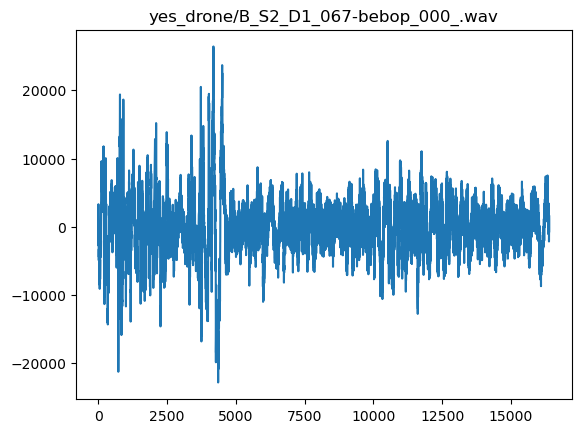

In [6]:
plt.plot(data)
plt.title(filename)
plt.show()
plt.close()

That looks like an audio file, good!

## Types of files

Lets look at the types of files we have in our data set

The data is located in `\Binary_Drone_Audio` with two folders: `unknown` and `yes_drone`.

In [7]:
import glob
glob.glob('Binary_Drone_Audio/*')

['Binary_Drone_Audio/yes_drone', 'Binary_Drone_Audio/unknown']

The `yes_drone` folder has `.wav` files tagged as drone noises. There are 1332 `yes_drone` files.

The `unknown` folder has `.wav` files tagged as drone noises. There are 10372 `unknown` files.

Each file is around 30 kb, with 67 `unknown` files ~160 kb

In [8]:
yes_drone_files = glob.glob('Binary_Drone_Audio/yes_drone/*')
unknown_files = glob.glob('Binary_Drone_Audio/unknown/*')
len(yes_drone_files), len(unknown_files)

(1332, 10372)

There are the following types of files in `yes_drone`:

* B_S2_D1_*_bebop_000 - 004
* extra_membo_D2_2000 - 2025
* Membo_0_***_membo_000 - 004
* Membo_1_***_membo_000 - 004
* Membo_2_***_membo_000 - 004
* mixed_..._bebop_000 - 004
* mixed_membo..._000 - 004

bebop --> Parrot Bebop, membo --> mambo drone? 

There are the following types of files in `unknown`:

* 1_... - 5_...
* doing_the_dishes
* exercise_bike
* pink_noise
* running_tap
* silence
* white_noise

## Waveforms

Lets look at a waveform from each yes type:

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


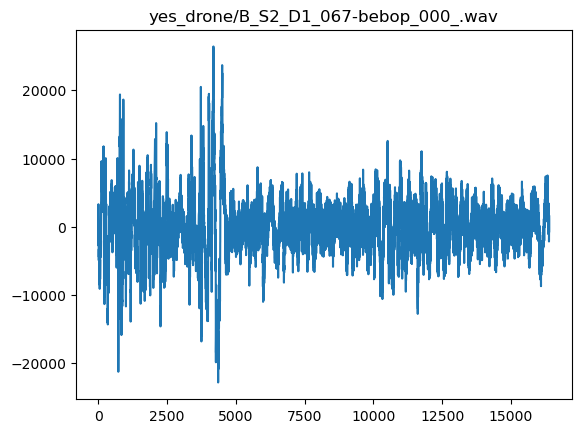

40.0 Hz, amplitude 1358.691
92.8 Hz, amplitude 708.183
160.2 Hz, amplitude 521.262
67.4 Hz, amplitude 496.898
124.0 Hz, amplitude 453.911
216.8 Hz, amplitude 422.604
390.6 Hz, amplitude 367.863
184.6 Hz, amplitude 330.039
266.6 Hz, amplitude 305.127
307.6 Hz, amplitude 244.895


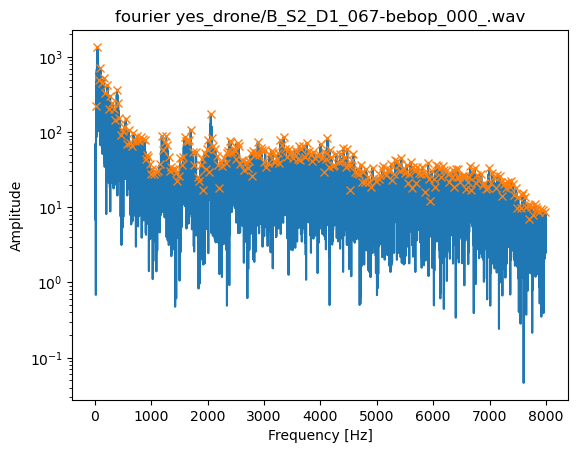

Sample Rate: 16000 Hz
Data Shape: (16027,)
length of clip: 1.0016875 seconds


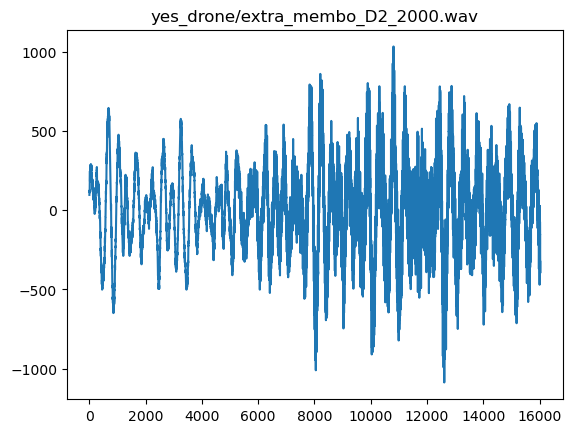

37.9 Hz, amplitude 157.917
17.0 Hz, amplitude 22.253
98.8 Hz, amplitude 20.787
75.9 Hz, amplitude 19.493
1254.9 Hz, amplitude 9.860
1791.0 Hz, amplitude 8.899
1834.9 Hz, amplitude 8.856
2526.7 Hz, amplitude 8.585
580.0 Hz, amplitude 8.212
1714.1 Hz, amplitude 7.886


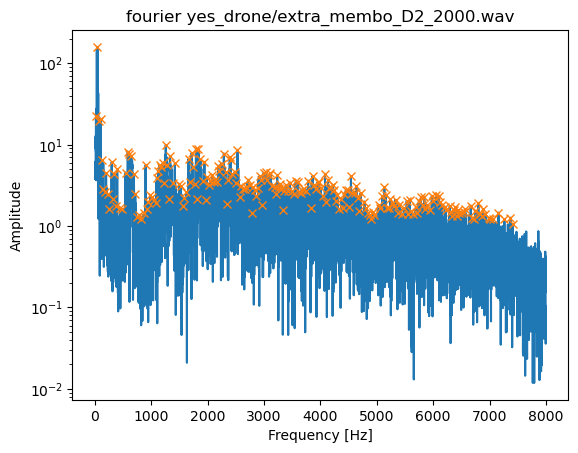

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


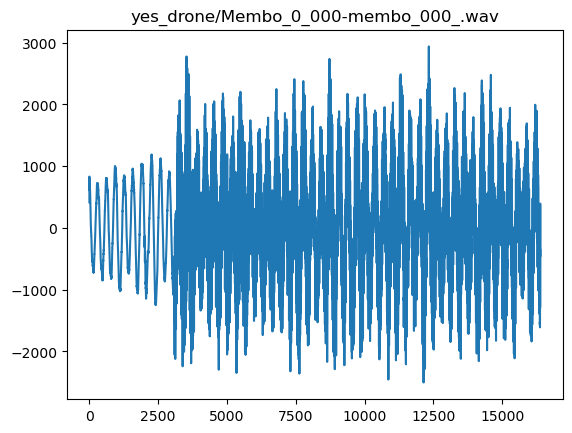

48.8 Hz, amplitude 597.153
637.7 Hz, amplitude 260.066
612.3 Hz, amplitude 97.328
1862.3 Hz, amplitude 78.246
1275.4 Hz, amplitude 69.645
24.4 Hz, amplitude 59.035
1249.0 Hz, amplitude 51.615
2499.0 Hz, amplitude 43.662
918.9 Hz, amplitude 43.657
3192.4 Hz, amplitude 41.652


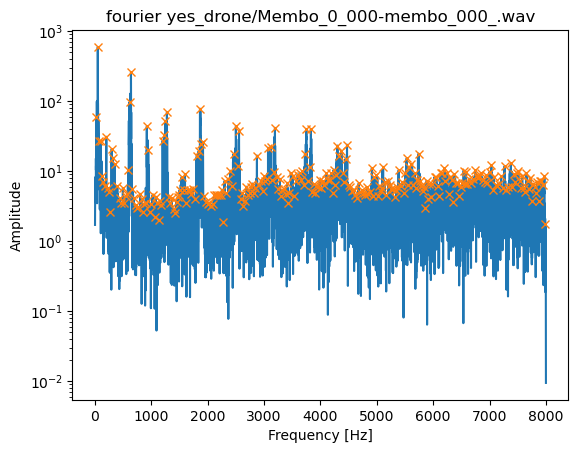

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


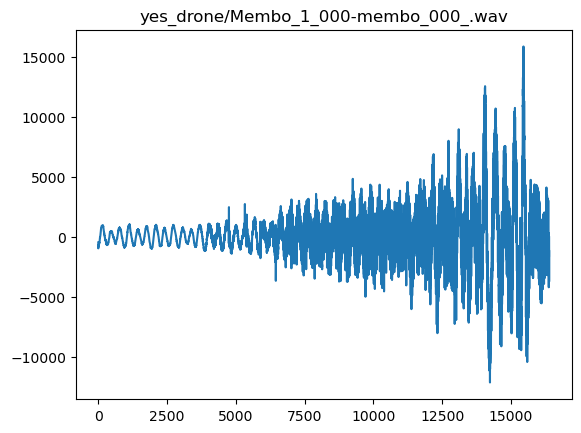

48.8 Hz, amplitude 870.200
69.3 Hz, amplitude 431.460
24.4 Hz, amplitude 223.960
92.8 Hz, amplitude 214.236
673.8 Hz, amplitude 152.943
625.0 Hz, amplitude 137.389
574.2 Hz, amplitude 119.681
651.4 Hz, amplitude 110.356
141.6 Hz, amplitude 87.128
116.2 Hz, amplitude 72.063


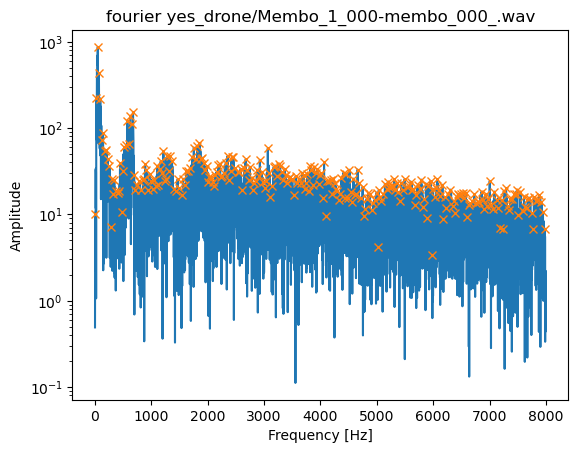

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


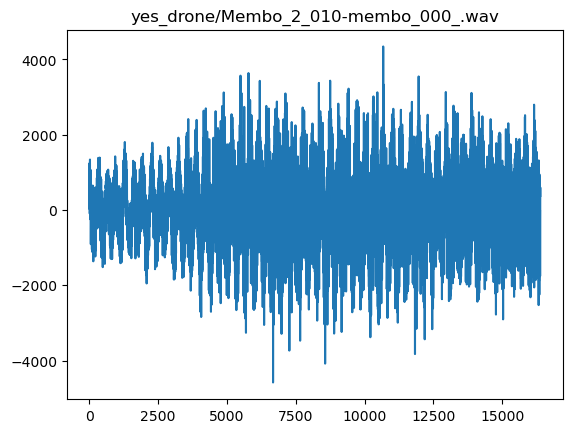

49.8 Hz, amplitude 569.061
1273.4 Hz, amplitude 87.153
1221.7 Hz, amplitude 83.541
641.6 Hz, amplitude 83.206
3202.1 Hz, amplitude 82.539
1182.6 Hz, amplitude 69.802
593.8 Hz, amplitude 68.996
1797.9 Hz, amplitude 63.191
4494.1 Hz, amplitude 57.264
1928.7 Hz, amplitude 56.430


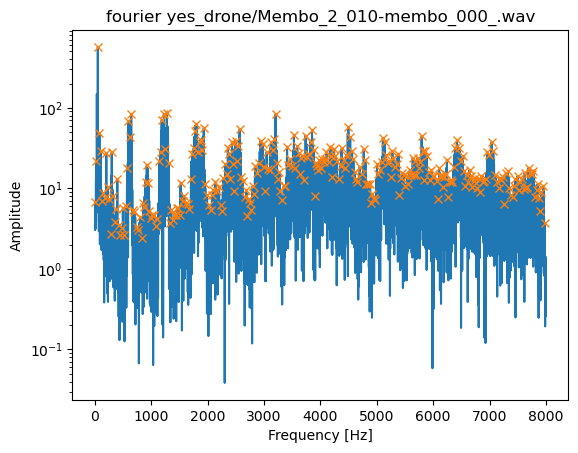

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


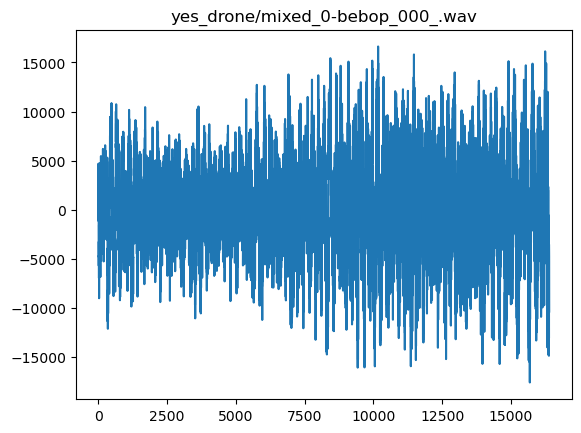

74.2 Hz, amplitude 1987.704
47.9 Hz, amplitude 627.879
120.1 Hz, amplitude 595.106
301.8 Hz, amplitude 486.180
321.3 Hz, amplitude 446.275
243.2 Hz, amplitude 409.309
280.3 Hz, amplitude 377.811
350.6 Hz, amplitude 375.518
98.6 Hz, amplitude 308.357
218.8 Hz, amplitude 296.598


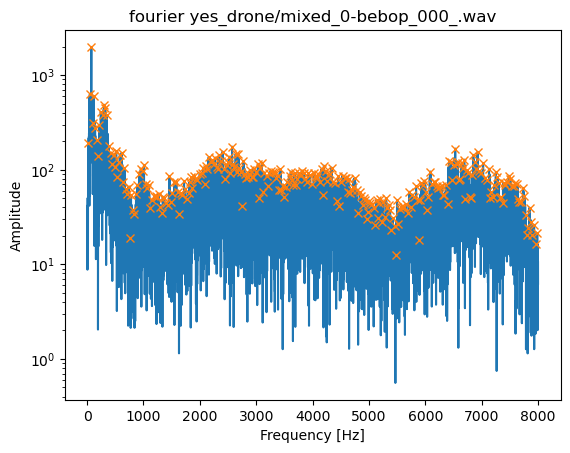

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


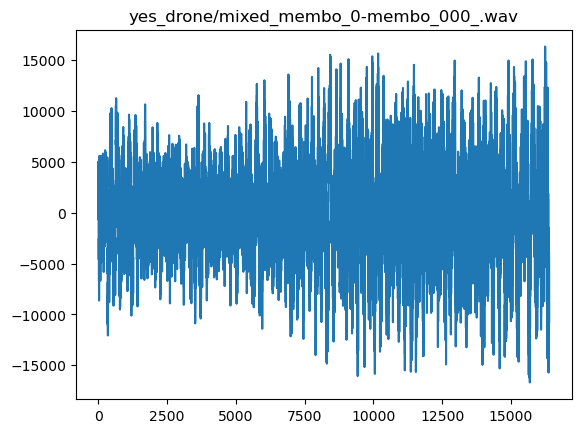

74.2 Hz, amplitude 2006.962
49.8 Hz, amplitude 729.600
120.1 Hz, amplitude 597.541
301.8 Hz, amplitude 484.589
321.3 Hz, amplitude 443.947
243.2 Hz, amplitude 408.301
280.3 Hz, amplitude 379.177
350.6 Hz, amplitude 373.819
97.7 Hz, amplitude 308.121
218.8 Hz, amplitude 298.037


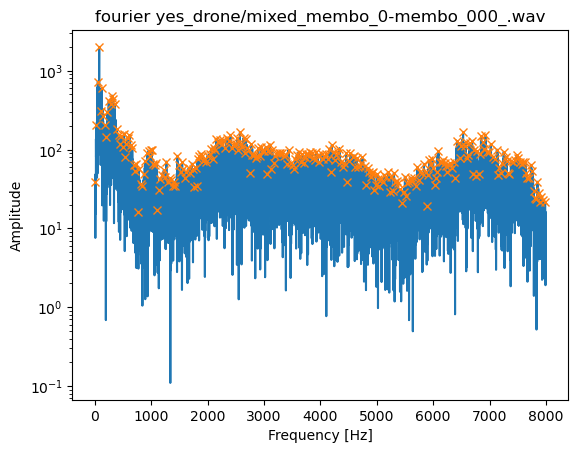

In [23]:
base = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'

filenames_yes = ['yes_drone/B_S2_D1_067-bebop_000_.wav', 'yes_drone/extra_membo_D2_2000.wav', 'yes_drone/Membo_0_000-membo_000_.wav', 
                 'yes_drone/Membo_1_000-membo_000_.wav', 'yes_drone/Membo_2_010-membo_000_.wav', 'yes_drone/mixed_0-bebop_000_.wav',
                 'yes_drone/mixed_membo_0-membo_000_.wav']

for filename in filenames_yes:
    samplerate, data = wavfile.read(base + filename)
    #samplerate, data = wavfile.read()
    
    N = data.shape[0]
    T = 1.0 / samplerate

    print(f"Sample Rate: {samplerate} Hz")
    print(f"Data Shape: {data.shape}")
    print(f'length of clip: {data.shape[0] / samplerate} seconds')

    plt.plot(data)
    plt.title(filename)
    plt.show()
    plt.close()

    yf = rfft(data)
    xf = rfftfreq(N, T)

    magnitude = np.abs(yf) * 2.0 / N

    peaks, properties = find_peaks(magnitude, prominence=1, distance=20)

    peak_freqs = xf[peaks]
    peak_amps  = magnitude[peaks]

    idx = np.argsort(peak_amps)[::-1]

    peak_freqs = peak_freqs[idx]
    peak_amps  = peak_amps[idx]

    for f, a in zip(peak_freqs[:10], peak_amps[:10]):
        print(f"{f:.1f} Hz, amplitude {a:.3f}")

    plt.plot(xf, magnitude)
    plt.plot(xf[peaks], magnitude[peaks], 'x')
    plt.semilogy()
    plt.title(f'fourier {filename}')
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Amplitude")
    plt.show()

## dB plot

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


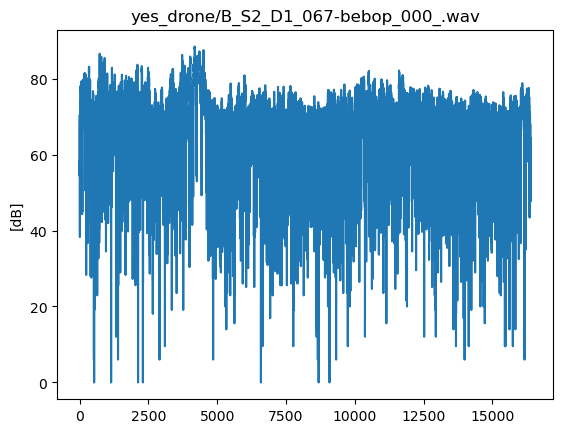

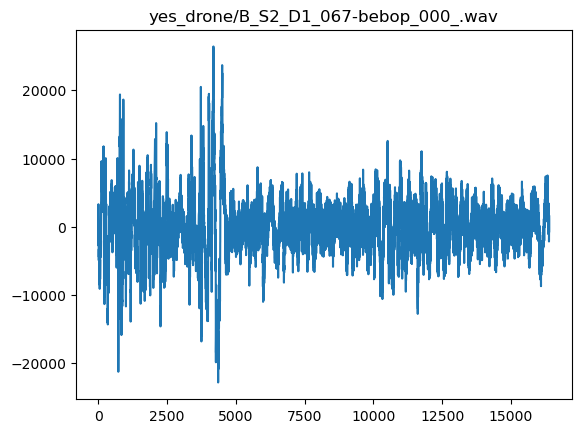

In [26]:
def convert_to_decibel(arr):
    ref = 1
    if arr!=0:
        return 20 * np.log10(abs(arr) / ref)
        
    else:
        return -60
    
base = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'
filename = 'yes_drone/B_S2_D1_067-bebop_000_.wav'
samplerate, data = wavfile.read(base + filename)

dataDB = [convert_to_decibel(i) for i in data]
print(f"Sample Rate: {samplerate} Hz")
print(f"Data Shape: {data.shape}")
print(f'length of clip: {data.shape[0] / samplerate} seconds')

plt.plot(dataDB)
plt.title(filename)
plt.ylabel('[dB]')
plt.show()
plt.close()

plt.plot(data)
plt.title(filename)
plt.show()
plt.close()

## What to extract

taken form ml finding drones here: 10.1016/j.procs.2022.09.140

* Chromagram: Provides a representation of the chromagram automatically collected from a waveform; Spectral Centroid: indicates where the ’centre of mass’ of an audio sample is located and this characteristic can be obtained as the relative average of the audio frequencies; 
* Spectral Bandwidth: as the name suggests, it relates to the bandwidth of the spectrum; 
* Spectral Rolloff: is represented as the frequency below which a certain percentage of the total spectral energy lies
* Mel-Frequency Cepstral Coefficients: indicated with the acronym Mel-Frequency Cepstral Coefficients: referred to as MFCC, is used to represent the shape of a spectral envelope. The The range of numerical values that this function can assume goes from 1 to 20. 20

## Fourier mess around
Lets take the fourier transform of this sample and look at the frequencies present. I'm not sure if this is entirely right...

### Inital mess around

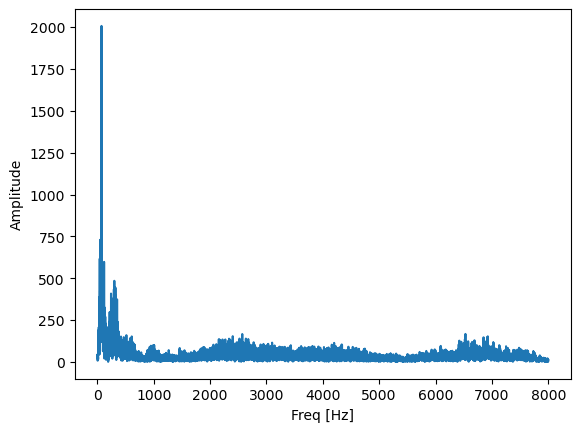

In [13]:
N = data.shape[0]
T = 1.0 / samplerate
yf = fft(data)
xf = fftfreq(N, T)[:N//2]

plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.xlabel('Freq [Hz]')
plt.ylabel('Amplitude')
plt.show()
plt.close()

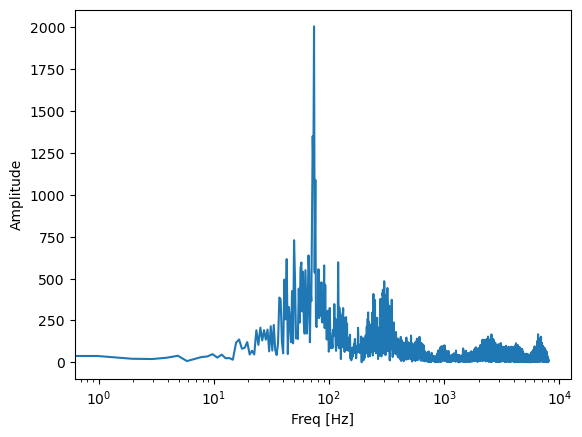

In [14]:
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.xlabel('Freq [Hz]')
plt.ylabel('Amplitude')
plt.semilogx()
plt.show()
plt.close()

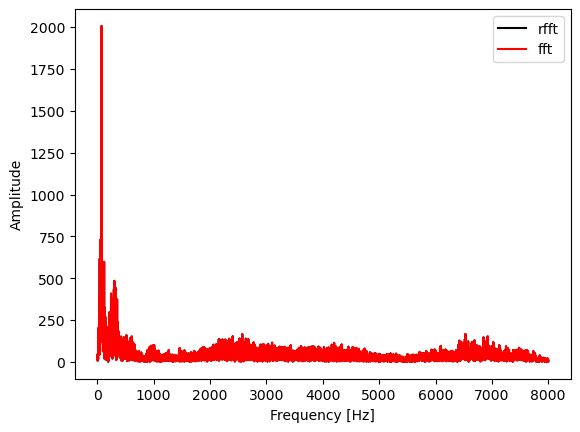

In [15]:

yfr = rfft(data)
xfr = rfftfreq(N, T)

yf = fft(data)
xf = fftfreq(N, T)[:N//2]

plt.plot(xfr, np.abs(yfr) * 2.0 / N, label='rfft', color='k')
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]), label='fft', color='r', linestyle='solid')
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.show()


Lets look at the residuals from `rff` vs `fff`

Text(0.5, 0, 'Frequency [Hz]')

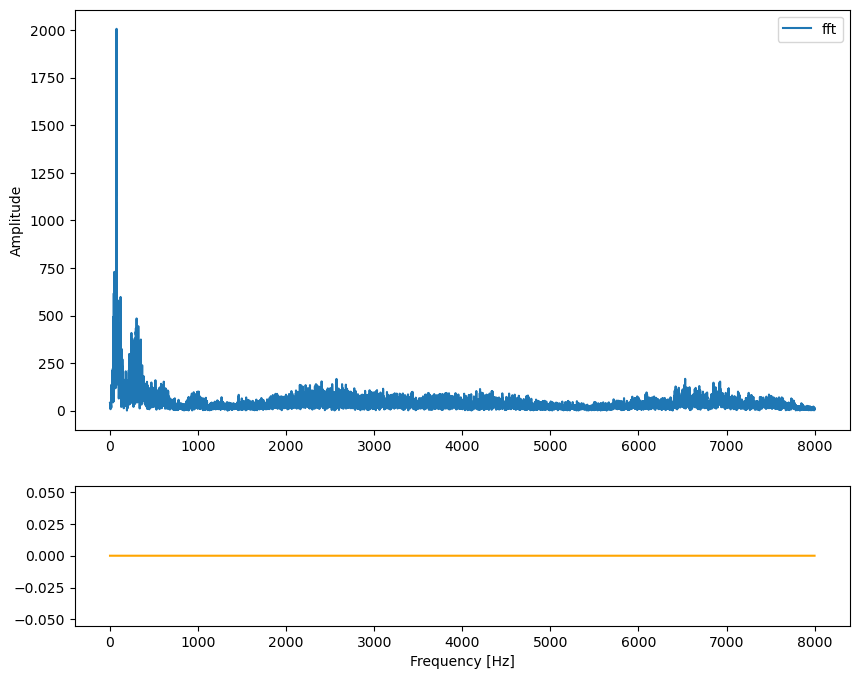

In [16]:
from matplotlib import gridspec

fig = plt.figure(figsize=(10,8))

gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
ax_main = plt.subplot(gs[0])
ax_main.plot(xf, 2.0/N * np.abs(yf[0:N//2]), label='fft')
ax_main.set_ylabel('Amplitude')
ax_main.legend()    

ax_residuals = plt.subplot(gs[1], sharex=ax_main)
residuals = (2.0/N * np.abs(yf[0:N//2])) - (2.0/N * np.abs(yfr[:-1]))
ax_residuals.plot(xf, residuals, label='Residuals', color='orange')
ax_residuals.set_xlabel('Frequency [Hz]')

### Freq peak
Chat about getting the peaks from data

40.0 Hz, amplitude 1358.691
92.8 Hz, amplitude 708.183
160.2 Hz, amplitude 521.262
67.4 Hz, amplitude 496.898
124.0 Hz, amplitude 453.911
216.8 Hz, amplitude 422.604
390.6 Hz, amplitude 367.863
184.6 Hz, amplitude 330.039
266.6 Hz, amplitude 305.127
307.6 Hz, amplitude 244.895


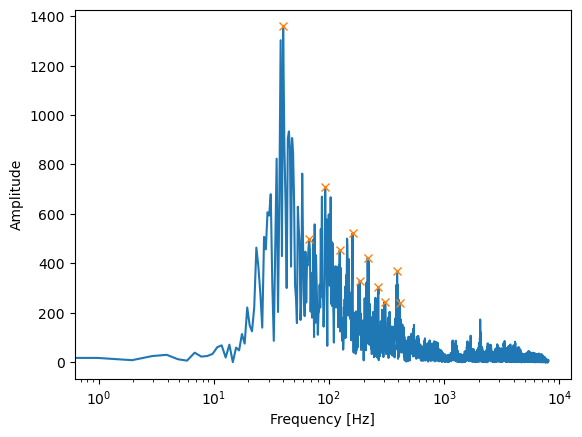

In [17]:
samplerate, data = wavfile.read('/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/yes_drone/B_S2_D1_067-bebop_000_.wav')

N = data.shape[0]
T = 1.0 / samplerate

yf = rfft(data)
xf = rfftfreq(N, T)

magnitude = np.abs(yf) * 2.0 / N

peaks, properties = find_peaks(magnitude, prominence=200, distance=20)

peak_freqs = xf[peaks]
peak_amps  = magnitude[peaks]

idx = np.argsort(peak_amps)[::-1]

peak_freqs = peak_freqs[idx]
peak_amps  = peak_amps[idx]

for f, a in zip(peak_freqs[:10], peak_amps[:10]):
    print(f"{f:.1f} Hz, amplitude {a:.3f}")

plt.plot(xf, magnitude)
plt.plot(xf[peaks], magnitude[peaks], 'x')
plt.semilogx()
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.show()

#from scipy.ndimage import gaussian_filter1d
#magnitude_smooth = gaussian_filter1d(magnitude, sigma=2)